# L2 课程笔记：监督学习（Supervised Learning）导论

> **资料对应关系。** 核心内容顺序遵循 L2 slides（第 2-42 页）。以下补充参考了 *Learning Theory from First Principles* 的第 2.2-2.5、3.9、6.2-6.3 节，以及 *Understanding Machine Learning: Solution Manual* 第 19 节中的最近邻论证。



## 1. 监督学习（supervised learning）：基本设定（basic setup）

在监督学习中，我们得到一组带标签样本（labeled examples），并希望学习一个能够在未见数据（unseen data）上准确预测的预测规则（prediction rule）。

训练集写作

$$
S=\{(x_1,y_1),\ldots,(x_n,y_n)\}\subseteq \mathcal X\times \mathcal Y.
$$

其中：

- $\mathcal X$ 是**数据域**（data domain），通常为 $\mathbb R^d$。
- $\mathcal Y$ 是**标签域**（label domain）。
- **分类器**（classifier）或**假设**（hypothesis）是一个函数

$$
h:\mathcal X\to \mathcal Y.
$$

对于二分类（binary classification），常见的标签集合为

$$
\mathcal Y=\{0,1\}
\quad\text{或}\quad
\mathcal Y=\{-1,+1\}.
$$

对于回归（regression），输出是数值，例如

$$
\mathcal Y=\mathbb R
\quad\text{或}\quad
\mathcal Y=\mathbb R^m.
$$

因此，两者的区别是

$$
\text{分类：离散标签},
\qquad
\text{回归：连续/数值标签}.
$$

---



## 2. 分类的概率模型（probabilistic model）

本讲假设数据由某个未知但固定的联合分布（joint distribution）生成：

$$
P \quad \text{定义在} \quad \mathcal X\times \mathcal Y \text{上}.
$$

一个随机数据点记作

$$
(X,Y)\sim P.
$$

对于二元标签 $\mathcal Y=\{0,1\}$，定义条件类别概率（conditional class probability）

$$
\eta(x)=P(Y=1\mid X=x)=\mathbb E[Y\mid X=x].
$$

分类器 $h$ 的**风险**（risk），也称为**泛化误差**（generalization error），定义为

$$
L(h)=P(h(X)\neq Y).
$$

等价地，

$$
L(h)=\mathbb E\left[\mathbf 1_{\{h(X)\neq Y\}}\right].
$$

这是总体误差（population error），而不仅仅是训练误差（training error）。

### 固定预测器（fixed predictor）与学习得到的预测器（learned predictor）

当 $h$ 和数据生成分布（data-generating distribution）$P$ 都固定时，$L(h)$ 是一个确定的数。但学习算法（learning algorithm）的输出 $h_S=A(S)$ 依赖于随机训练样本（random training sample）$S$，因此

$$
L(h_S)=P(h_S(X)\neq Y\mid S)
$$

在观察到 $S$ 之前本身也是随机的。描述学习算法性能的两种常见方式是期望性能（expected performance）

$$
\mathbb E_S[L(h_S)]
$$

以及如下形式的高概率保证（high-probability guarantee）：

$$
P_S\bigl(L(h_S)-L^*\le \varepsilon\bigr)\ge 1-\delta.
$$

---



## 3. Bayes 分类器（Bayes classifier）

目标是找到风险尽可能小的分类器：

$$
\inf_h L(h).
$$

对于二分类，Bayes 分类器为

$$
h^*(x)=
\begin{cases}
1, & \eta(x)>\frac12,\\
0, & \eta(x)\le \frac12.
\end{cases}
$$

直观上，如果给定 $X=x$ 后类别 $1$ 比类别 $0$ 更可能出现，就预测 $1$；否则预测 $0$。

当 $\eta(x)=1/2$ 时，两种标签具有相同的条件误差，因此如何处理平局不影响最优性。

### Bayes 规则（Bayes rule）依赖于损失函数（loss function）

逐点 Bayes 原理（pointwise Bayes principle）比 0/1 分类更加一般。对于损失函数 $\ell(y,z)$，定义条件风险（conditional risk）


z为预测lable

$$
r(z\mid x)=\mathbb E[\ell(Y,z)\mid X=x].
$$

Bayes 预测器（Bayes predictor）选择

$$
f^*(x)\in\operatorname*{argmin}_{z\in\mathcal Y}r(z\mid x).
$$

由此得到几个重要的特殊情形：

- 0/1 损失（0/1 loss）：选择条件概率最大的类别。
- 平方损失（squared loss）：$f^*(x)=\mathbb E[Y\mid X=x]$。
- 绝对值损失（absolute loss）：$Y\mid X=x$ 的任意条件中位数（conditional median）都是 Bayes 最优的。

对于代价敏感二分类（cost-sensitive binary classification），令 $c_{\mathrm{FP}}$ 为假阳性（false positive）的代价，$c_{\mathrm{FN}}$ 为假阴性（false negative）的代价。预测类别 $1$ 最优，当且仅当

$$
c_{\mathrm{FP}}(1-\eta(x))\le c_{\mathrm{FN}}\eta(x),
$$

等价地，

$$
\eta(x)\ge\frac{c_{\mathrm{FP}}}{c_{\mathrm{FP}}+c_{\mathrm{FN}}}.
$$

因此，熟悉的阈值 $1/2$ 是两类错误代价相等的结果，而不是普遍适用的规则。

---



## 4. 证明：Bayes 分类器是最优的

我们证明，对于任意分类器 $h:\mathcal X\to\{0,1\}$，都有

$$
L(h^*)\le L(h).
$$

固定 $x\in\mathcal X$。若预测为 $1$，条件错误概率是

$$
P(1\neq Y\mid X=x)=P(Y=0\mid X=x)=1-\eta(x).
$$

若预测为 $0$，条件错误概率是

$$
P(0\neq Y\mid X=x)=P(Y=1\mid X=x)=\eta(x).
$$

所以在每个固定的 $x$ 处，最优预测应选择条件误差较小的类别，其误差为

$$
\min\{\eta(x),1-\eta(x)\}.
$$

Bayes 分类器恰好完成了这一选择：

- 若 $\eta(x)>1/2$，则 $1-\eta(x)<\eta(x)$，所以预测 $1$；
- 若 $\eta(x)\le1/2$，则 $\eta(x)\le1-\eta(x)$，所以预测 $0$。

因此对每个 $x$，

$$
P(h^*(X)\neq Y\mid X=x)
\le
P(h(X)\neq Y\mid X=x).
$$

对 $X$ 取期望，并使用全期望公式，得到

$$
P(h^*(X)\neq Y)
\le
P(h(X)\neq Y).
$$

所以

$$
L(h^*)\le L(h).
$$

因此 $h^*$ 是最优分类器。

---



## 5. Bayes 误差（Bayes error）

**Bayes 误差**是可能达到的最小分类误差：

$$
L^*=\inf_{h:\mathcal X\to\{0,1\}} P(h(X)\neq Y).
$$

由于 Bayes 分类器是最优的，

$$
L^*=L(h^*).
$$

在每个 $x$ 处，Bayes 分类器的条件误差为

$$
\min\{\eta(x),1-\eta(x)\}.
$$

因此

$$
L^*=\mathbb E\left[\min\{\eta(X),1-\eta(X)\}\right].
$$

下面证明另一种表达式：

$$
L^*=\frac12-\frac12\mathbb E\left[|2\eta(X)-1|\right].
$$

对于任意 $a\in[0,1]$，

$$
\min\{a,1-a\}=\frac12-\left|a-\frac12\right|.
$$

又因为

$$
\left|a-\frac12\right|=\frac12|2a-1|,
$$

所以

$$
\min\{a,1-a\}=\frac12-\frac12|2a-1|.
$$

令 $a=\eta(X)$ 并取期望，即得

$$
L^*=\frac12-\frac12\mathbb E\left[|2\eta(X)-1|\right].
$$

---



## 6. 为什么 Bayes 分类器是理想化的？

Bayes 分类器要求我们知道

$$
\eta(x)=P(Y=1\mid X=x).
$$

但在实际监督学习中，分布 $P$ 虽然固定，但未知。我们只能观察有限训练集

$$
S=\{(x_i,y_i)\}_{i=1}^n.
$$

因此，Bayes 分类器通常无法直接计算。它是一个理想基准：如果完整的数据生成分布已知，它给出了任何分类器所能达到的最佳风险。

---



## 7. 多分类 Bayes 分类器（multiclass Bayes classifier）

对于 $K$ 个类别，

$$
\mathcal Y=\{1,2,\ldots,K\}.
$$

定义

$$
\eta_i(x)=P(Y=i\mid X=x).
$$

Bayes 分类器为

$$
h^*(x)\in \operatorname*{argmax}_{1\le i\le K} P(Y=i\mid X=x).
$$

实际等价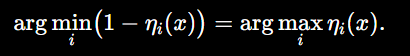

也就是说，它预测给定 $X=x$ 时最可能出现的类别。

### 多分类最优性的证明

对于任意分类器 $h$，

$$
P(h(X)\neq Y\mid X=x)=1-P(Y=h(x)\mid X=x).
$$

对于 Bayes 分类器，

$$
P(h^*(X)\neq Y\mid X=x)=1-P(Y=h^*(x)\mid X=x).
$$

因为 $h^*(x)$ 最大化了条件概率，

$$
P(Y=h^*(x)\mid X=x)
\ge
P(Y=h(x)\mid X=x).
$$

所以

$$
P(h^*(X)\neq Y\mid X=x)
\le
P(h(X)\neq Y\mid X=x).
$$

对 $X$ 取期望得到

$$
L(h^*)\le L(h).
$$

当 $K=2$ 时，它退化为前面的二分类规则，因为

$$
P(Y=1\mid X=x)>\frac12
\iff
P(Y=1\mid X=x)>P(Y=0\mid X=x).
$$


**这里的$P(Y=1\mid X=x)>\frac12$ 时判断阈值，并不是一个固定条件，是说当满足这个情况时， 判断为1 类**

---



## 8. 最近邻分类（nearest-neighbor classification）

$k$-最近邻分类器（$k$-nearest-neighbor classifier, $k$-NN）是一种简单的非参数方法（nonparametric method）。

训练阶段（training phase）：保存训练数据。

预测阶段（prediction phase）：对于测试点 $x$，

1. 找到距离 $x$ 最近的 $k$ 个训练点；
2. 通过多数投票（majority vote）预测这些近邻标签中的多数类别。

当 $k=1$ 时，分类器直接预测最近训练点的标签。

由于预测直接依赖训练样本的几何结构，最近邻分类器可以形成复杂的非线性决策边界（nonlinear decision boundary）。

### 选择 $k$：平滑（smoothing）、方差（variance）与维数（dimension）

$k$ 是超参数（hyperparameter），而不是通过 ERM 拟合的模型参数。较小的 $k$ 使规则更灵活、平滑偏差（smoothing bias）较小，但对具体样本更加敏感。增大 $k$ 会平均更多标签并降低方差，但也可能模糊真实的类别边界。实践中应使用验证数据（validation data）选择 $k$ 和距离度量（distance metric）。

最近邻方法也体现了维数灾难（curse of dimensionality）：在高维空间中，即使样本量很大，也可能找不到真正“局部”的邻居。在 $\mathbb R^d$ 中，朴素搜索（naive search）每次查询需要 $O(nd)$ 的距离计算；在条件合适时，空间索引（spatial index）或近似搜索（approximate search）可以降低这一代价。

标准的有限划分分析（finite-partition analysis）可以显式展示样本量问题。若将 $\mathcal X$ 划分为 $r$ 个单元 $C_1,\ldots,C_r$，则分类误差可以分解为：测试点落入样本不足单元（under-sampled cell）的概率，加上样本充足单元内的条件误差。对于 $k\ge2$，解答手册中的论证给出，样本点少于 $k$ 的单元所占概率质量的期望满足

$$
\mathbb E_S\left[
\sum_{j:\,|C_j\cap S|<k}P_X(C_j)
\right]\le \frac{2rk}{n}.
$$

这说明划分精度 $r$、邻域大小 $k$ 与样本量 $n$ 必须相互平衡。

---



## 9. 渐近（asymptotic）1-NN 误差与 Bayes 误差

slides 指出，在渐近意义下，1-最近邻分类器的误差为

$$
L_{\mathrm{NN}}=\mathbb E\left[2\eta(X)(1-\eta(X))\right].
$$

直观上，当 $n\to\infty$ 时，$X=x$ 的最近邻会非常接近 $x$。在适当的正则性条件（regularity conditions）下，该近邻的标签近似服从条件分布（conditional distribution）$P(Y\mid X=x)$ 的一个独立抽样（independent sample）。

令 $Y$ 为测试点的真实标签，$Y'$ 为最近邻的标签。给定 $X=x$，

$$
P(Y=1\mid X=x)=\eta(x),
$$

并且近似有

$$
P(Y'=1\mid X=x)=\eta(x).
$$

当 $Y'\neq Y$ 时，1-NN 分类器出错：

$$
\begin{aligned}
P(Y'\neq Y\mid X=x)
&=P(Y'=1,Y=0\mid X=x)+P(Y'=0,Y=1\mid X=x)\\
&=\eta(x)(1-\eta(x))+(1-\eta(x))\eta(x)\\
&=2\eta(x)(1-\eta(x)).
\end{aligned}
$$

对 $X$ 取期望，得到

$$
L_{\mathrm{NN}}=\mathbb E\left[2\eta(X)(1-\eta(X))\right].
$$

---



## 10. 证明：$L_{\mathrm{NN}}\le 2L^*$

令

$$
A(X)=\min\{\eta(X),1-\eta(X)\}.
$$

则

$$
L^*=\mathbb E[A(X)].
$$

同时，

$$
\eta(X)(1-\eta(X))=A(X)(1-A(X)).
$$

所以

$$
L_{\mathrm{NN}}=2\mathbb E[A(X)(1-A(X))].
$$

利用

$$
\mathbb E[A(1-A)]=\mathbb E[A]-\mathbb E[A^2].
$$

又因为

$$
\mathbb E[A^2]\ge (\mathbb E[A])^2,
$$

这里使用了方差非负性（non-negativity of variance）：$\operatorname{Var}(A)\ge 0$。

所以

$$
\mathbb E[A(1-A)]
\le
\mathbb E[A](1-\mathbb E[A]).
$$

因此

$$
L_{\mathrm{NN}}
\le
2L^*(1-L^*)
\le
2L^*.
$$

于是，渐近 1-最近邻的误差至多是 Bayes 误差的两倍：

$$
L_{\mathrm{NN}}\le 2L^*.
$$

---



## 11. 无免费午餐（No-Free-Lunch）思想

无免费午餐定理（No-Free-Lunch theorem）说明，不存在能够在所有可能的数据分布上都成功的万能学习器。

更准确地说：对于任意学习算法，都存在某个分布使该算法表现很差，即使另一个算法可能在同一分布上表现良好。

这**并不**意味着学习不可能。它意味着学习必须依赖某些假设，例如

$$
\text{平滑性},\quad
\text{低维结构},\quad
\text{有用的假设类},\quad
\text{有意义的度量},\quad
\text{或先验知识}.
$$

因此，该定理解释了为什么归纳偏置（inductive bias）是必要的。

一个精确的固定样本量表述如下。若 $\mathcal X$ 是无限集，则对任意学习算法 $A$ 和任意固定的 $n$，

$$
\sup_P\;\mathbb E_{S\sim P^n}\left[
L_P(A(S))-L_P^*
\right]\ge\frac12.
$$

证明思路：在 $m\gg n$ 个输入点上均匀分配概率，并为它们赋予确定但任意的二元标签。Bayes 风险为零，但大多数测试输入没有出现在训练集中；对所有标签赋值取平均时，任何算法都只能在这些未见输入上猜测。令 $m$ 增大即可得到该下界。

困难分布可以依赖于 $n$。因此，该定理并不与普遍一致性（universal consistency）矛盾：普遍一致性固定一个分布并令 $n\to\infty$；No-Free-Lunch 排除的是对所有可能问题都成立的、与分布无关的收敛速率（distribution-free convergence rate）。

这也回答了 slides 中的问题：“这是否说明我们不能总是达到 Bayes 分类器的水平？”

答案是：不存在一个有限样本的万能学习器，能对所有分布保证达到 Bayes 水平。对于特定分布，在有适当假设并有足够数据时，我们可以逼近 Bayes 风险；但若没有任何假设，就无法对所有任务给出这样的保证。


**从这一角度看，优化过程是在给定假设类中寻找对 Bayes 预测器（Bayes predictor）的最佳逼近。**


---



## 12. 一般损失函数（general loss function）

除了分类错误率，还可以定义一般的非负损失

$$
\ell:\mathcal H\times \mathcal X\times \mathcal Y\to \mathbb R_+.
$$

总体风险（population risk）为

$$
L(h)=\mathbb E[\ell(h,X,Y)].
$$

经验风险（empirical risk）为

$$
L_S(h)=\frac1n\sum_{i=1}^n \ell(h,x_i,y_i).
$$

对于分类，0/1 损失（0/1 loss）定义为

$$
\ell_{0/1}(h,(x,y))=
\begin{cases}
1, & h(x)\neq y,\\
0, & h(x)=y.
\end{cases}
$$

于是

$$
\mathbb E[\ell_{0/1}(h,(X,Y))]
=\mathbb E\left[\mathbf 1_{\{h(X)\neq Y\}}\right]
=P(h(X)\neq Y).
$$

所以 0/1 损失恢复了前面定义的分类风险。

---



## 13. 间隔损失（margin losses）

对于标签 $y\in\{-1,+1\}$ 的二分类和评分函数（score function）$f_\theta(x)$，定义间隔（margin）

$$
z=yf_\theta(x).
$$

置信度高的正确预测具有较大的正间隔 $z$。

常见损失包括

$$
\ell_{0/1}(z)=\mathbf 1_{\{z\le 0\}},
$$

$$
\ell_{\mathrm{hinge}}(z)=\max\{0,1-z\},
$$

以及

$$
\ell_{\log}(z)=\log(1+e^{-z}).
$$

合页损失（hinge loss）是 0/1 损失的凸上界（convex upper bound）。Logistic 损失（logistic loss）是光滑凸替代损失（smooth convex surrogate loss）；经过适当缩放后，它也可以视为 0/1 损失的上界。这些损失比 0/1 损失更容易优化。

---



## 14. 经验风险最小化（empirical risk minimization, ERM）

由于真实分布 $P$ 未知，真实风险

$$
L(h)=\mathbb E[\ell(h,X,Y)]
$$

通常无法直接计算。

经验风险最小化转而最小化经验风险：

$$
\operatorname{ERM}(S)
\in
\operatorname*{argmin}_{h\in\mathcal H} L_S(h).
$$

对于 0/1 损失，

$$
L_S(h)=\frac1n \sum_{i=1}^{N} l(h,x_i,y_i)=\frac1n\left|\{i\in[n]:h(x_i)\neq y_i\}\right|.
$$

ERM 原则可以概括为

$$
\text{选择使训练误差最小的假设(or parameters)}.
$$

主要风险是过拟合（overfitting）：分类器可能完美拟合训练数据，却在未见数据上表现很差。

---



## 15. 过拟合（overfitting）示例：记忆训练集（memorization）

定义分类器

$$
h(x)=
\begin{cases}
y_i, & x=x_i \text{ 对某个训练点 } x_i,\\
0, & \text{其他情况}.
\end{cases}
$$

该分类器的经验风险为零：

$$
L_S(h)=0.
$$

但假设 $X$ 服从连续分布，例如在单位正方形上均匀分布，而 $Y$ 是独立的公平硬币。新的测试点几乎必然不同于所有训练点：

$$
P(X\in\{x_1,\ldots,x_n\})=0.
$$

所以分类器几乎总是预测 $0$。由于

$$
P(Y=1)=\frac12,
$$

测试误差为

$$
L(h)=\frac12.
$$

因此，该分类器拥有完美的训练准确率，却只有随机猜测水平的测试性能。

不过，记忆并不总是坏事。当完全相同的输入会重复出现时，或者当记忆与有意义的几何假设结合时（如最近邻方法），它也可能有用。

---



## 16. 归纳偏置（inductive bias）与受限假设类（restricted hypothesis class）

为了让 ERM 有意义，我们将搜索空间限制在一个在观察训练数据之前选定的假设类 $\mathcal H$ 中。

在 $\mathcal H$ 上的 ERM 为

$$
\operatorname{ERM}_{\mathcal H}(S)
\in
\operatorname*{argmin}_{h\in\mathcal H} L_S(h).
$$

假设类的例子包括

$$
\text{线性分类器},\quad
\text{决策树},\quad
\text{随机森林},\quad
\text{神经网络}.
$$

一个好的假设类需要平衡

$$
\mathcal H \text{ 过大} \Rightarrow \text{过拟合（overfitting）},
$$

$$
\mathcal H \text{ 过小} \Rightarrow \text{欠拟合（underfitting）}.
$$

这就是归纳偏置的作用。

### 逼近误差（approximation error）与估计误差（estimation error）

令 $L^*$ 为不受限制的 Bayes 风险，$\widehat h$ 为从假设类 $\mathcal H$ 中学习得到的预测器，则

$$
L(\widehat h)-L^*
=\underbrace{L(\widehat h)-\inf_{h\in\mathcal H}L(h)}_{\text{估计误差}}
+\underbrace{\inf_{h\in\mathcal H}L(h)-L^*}_{\text{逼近误差}}.
$$

增大 $\mathcal H$ 会提供更多可选预测器，因此可能降低逼近误差，但通常也会增加估计难度。这就是欠拟合与过拟合权衡的统计表述。

估计误差衡量由有限训练样本造成的差距；逼近误差衡量受限假设类中的最优模型与 Bayes 模型之间的差距。二者都不同于优化误差（optimization error），后者来自算法未能精确求解经验风险最小化问题。

对于精确 ERM 解 $\widehat h$ 和 $\mathcal H$ 中的总体风险最小化器 $h_{\mathcal H}^*$，有用的确定性不等式为

$$
L(\widehat h)-L(h_{\mathcal H}^*)
\le 2\sup_{h\in\mathcal H}|L(h)-L_S(h)|.
$$

如果优化算法只能把经验风险降到距离最优值 $\varepsilon_{\mathrm{opt}}$ 的范围内，则在右侧再加上 $\varepsilon_{\mathrm{opt}}$。因此，总体性能由三个不同问题共同决定：逼近、估计/泛化（generalization）以及优化。控制 $\mathcal H$ 或正则化（regularization）强度的超参数（hyperparameter），应使用验证数据（validation data）选择，而不应在同一个训练损失上优化。

---



## 17. 为什么 0/1 损失（0/1 loss）的 ERM 很困难？

0/1 经验风险最小化问题为

$$
\min_{h\in\mathcal H}
\frac1n\sum_{i=1}^n \mathbf 1_{\{h(x_i)\neq y_i\}}.
$$

这个目标函数不连续（discontinuous）且非凸（nonconvex），因此通常很难优化。对于许多丰富的假设类，精确最小化是 NP-hard 的。

不过，它并非总是困难。容易处理的情形包括：

1. **较小的有限假设类（finite hypothesis class）**：若 $\mathcal H$ 有限且较小，可以计算每个 $h\in\mathcal H$ 的误差并选择最优者。
2. **一维阈值分类器（threshold classifier）**：令 $h_t(x)=\mathbf 1_{\{x\ge t\}}$，对数据排序并扫描所有可能的阈值。
3. **决策树桩（decision stump）**：对于深度为 1 的决策树，扫描每个特征和每个可能阈值。
4. **线性可分可行性问题（linearly separable feasibility problem）**：如果目标只是在线性可分数据中找到一个训练误差为零的分离器，可以使用感知机（perceptron）或线性规划（linear programming）。但在线性分类器中精确最小化错误数量，一般仍然很困难。

---



## 18. 将 ERM 写成有限和优化（finite-sum optimization）

许多机器学习训练问题具有如下形式：

$$
f(\theta)=\frac1n\sum_{i=1}^n f_i(\theta),
$$

其中 $\theta$ 表示模型参数。

通常，

$$
f_i(\theta)=\ell(h_\theta,x_i,y_i).
$$

所以经验风险最小化成为有限和优化问题：

$$
\min_\theta
\frac1n\sum_{i=1}^n \ell(h_\theta,x_i,y_i).
$$

其例子包括

$$
\text{logistic 回归},
\quad
\text{支持向量机},
\quad
\text{深度神经网络},
\quad
\text{最大似然估计}.
$$

---



## 19. 示例：最小二乘（least squares）作为有限和优化

对于数据矩阵（data matrix）$X\in\mathbb R^{n\times d}$ 和标签 $y\in\mathbb R^n$，最小二乘求解

$$
\min_\theta \frac12\|X\theta-y\|^2.
$$

记 $x_i^\top$ 为 $X$ 的第 $i$ 行，则

$$
\|X\theta-y\|^2=\sum_{i=1}^n (x_i^\top\theta-y_i)^2.
$$

因此

$$
\frac12\|X\theta-y\|^2
=
\sum_{i=1}^n \frac12(x_i^\top\theta-y_i)^2.
$$

单个样本对应的损失为

$$
f_i(\theta)=\frac12(x_i^\top\theta-y_i)^2.
$$

若使用平均形式，

$$
f(\theta)=\frac1n\sum_{i=1}^n f_i(\theta).
$$

---



## 20. 示例：神经网络（neural network）分类

令 $\operatorname{net}(\theta,x_i)$ 表示神经网络在输入 $x_i$ 上的输出。

分类器训练可以写成

$$
\min_\theta
\frac1n\sum_{i=1}^n
\ell(y_i,\operatorname{net}(\theta,x_i)).
$$

单个样本损失为

$$
f_i(\theta)=\ell(y_i,\operatorname{net}(\theta,x_i)).
$$

对于多分类，一个常用选择是交叉熵损失（cross-entropy loss）。

---



## 21. 示例：主成分分析（principal component analysis, PCA）作为有限和优化

通常的第一主成分问题为

$$
\max_{\|x\|=1}
x^\top
\left(
\sum_{i=1}^n z_i z_i^\top
\right)
x.
$$

等价地，它可以写成最小化问题

$$
\min_{\|x\|=1}
-x^\top
\left(
\sum_{i=1}^n z_i z_i^\top
\right)
x.
$$

由于

$$
x^\top z_i z_i^\top x=(z_i^\top x)^2,
$$

最小化目标可改写为

$$
\sum_{i=1}^n -(z_i^\top x)^2.
$$

因此单个样本对应的目标项为

$$
f_i(x)=-(z_i^\top x)^2.
$$

令

$$
C=\sum_{i=1}^n z_i z_i^\top.
$$

则 PCA 求解

$$
\max_{\|x\|=1} x^\top Cx.
$$

根据 Rayleigh 商（Rayleigh quotient）定理，解是 $C$ 的最大特征值所对应的特征向量（eigenvector）。

标准 PCA 必须先对观测进行中心化（centering）。令 $\bar z=n^{-1}\sum_i z_i$，经验协方差（empirical covariance）为

$$
\widehat C=\frac1n\sum_{i=1}^n(z_i-\bar z)(z_i-\bar z)^\top.
$$

将协方差乘以 $n$ 不会改变其特征向量，因此 slides 中未归一化的有限和在中心化后与标准形式等价。如果不中心化，首要方向可能主要反映均值偏移，而不是围绕均值的变化。

---



## 22. 本讲总结

主要内容如下：

- 真实风险为

$$
L(h)=P(h(X)\neq Y),
$$

但 $P$ 未知，因此不能直接最小化 $L(h)$。

- Bayes 分类器是理想的最优分类器：

$$
h^*(x)\in \operatorname*{argmax}_y P(Y=y\mid X=x).
$$

- 其风险就是 Bayes 误差：

$$
L^*=\mathbb E\left[\min\{\eta(X),1-\eta(X)\}\right].
$$

- 最近邻是实用的非参数分类方法。渐近 1-NN 满足

$$
L_{\mathrm{NN}}\le 2L^*.
$$

- ERM 用训练风险替代未知的总体风险：

$$
L_S(h)=\frac1n\sum_{i=1}^n \ell(h,x_i,y_i).
$$

- 不受限制的 ERM 可能过拟合，所以需要通过假设类 $\mathcal H$ 引入归纳偏置。

- 许多机器学习方法都可以归结为有限和优化：

$$
\min_\theta \frac1n\sum_{i=1}^n f_i(\theta).
$$

